In [5]:
import pandas as pd
import numpy as np

In [ ]:
hd=pd.read_excel(r"C:\Users\anadi\Desktop\Heart disease-Ctree.xlsx")

In [ ]:
hd.shape

In [ ]:
hd.head()

In [9]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            303 non-null    int64  
 1   Sex            303 non-null    object 
 2   Chest Pain     303 non-null    object 
 3   trestbps       303 non-null    int64  
 4   chol           303 non-null    int64  
 5   fbs            303 non-null    object 
 6   thalach        303 non-null    int64  
 7   exang          303 non-null    object 
 8   oldpeak        303 non-null    float64
 9   Heart Disease  303 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 23.8+ KB


In [17]:
hd_cat=hd.select_dtypes(object)

In [19]:
dummies = pd.get_dummies(hd_cat)

In [21]:
hd1=pd.concat([hd,dummies],axis="columns")

In [23]:
hd1.head()

,Age,Sex,Chest Pain,trestbps,chol,fbs,thalach,exang,oldpeak,Heart Disease,...,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes,Heart Disease_no,Heart Disease_yes
0,63,Male,cp1,145,233,no,150,no,2.3,no,...,True,False,False,False,True,False,True,False,True,False
1,67,Male,cp4,160,286,no,108,yes,1.5,yes,...,False,False,False,True,True,False,False,True,False,True
2,67,Male,cp4,120,229,no,129,yes,2.6,yes,...,False,False,False,True,True,False,False,True,False,True
3,37,Male,cp3,130,250,no,187,no,3.5,no,...,False,False,True,False,True,False,True,False,True,False
4,41,Female,cp2,130,204,no,172,no,1.4,no,...,False,True,False,False,True,False,True,False,True,False


In [25]:
hd2=hd1.drop(["Chest Pain","Sex","fbs","exang","Heart Disease"],axis="columns")

In [27]:
hd2.head()

,Age,trestbps,chol,thalach,oldpeak,Sex_Female,Sex_Male,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes,Heart Disease_no,Heart Disease_yes
0,63,145,233,150,2.3,False,True,True,False,False,False,True,False,True,False,True,False
1,67,160,286,108,1.5,False,True,False,False,False,True,True,False,False,True,False,True
2,67,120,229,129,2.6,False,True,False,False,False,True,True,False,False,True,False,True
3,37,130,250,187,3.5,False,True,False,False,True,False,True,False,True,False,True,False
4,41,130,204,172,1.4,True,False,False,True,False,False,True,False,True,False,True,False


In [35]:
x=hd2.iloc[:,0:15]

In [37]:
x

,Age,trestbps,chol,thalach,oldpeak,Sex_Female,Sex_Male,Chest Pain_cp1,Chest Pain_cp2,Chest Pain_cp3,Chest Pain_cp4,fbs_no,fbs_yes,exang_no,exang_yes
0,63,145,233,150,2.3,False,True,True,False,False,False,True,False,True,False
1,67,160,286,108,1.5,False,True,False,False,False,True,True,False,False,True
2,67,120,229,129,2.6,False,True,False,False,False,True,True,False,False,True
3,37,130,250,187,3.5,False,True,False,False,True,False,True,False,True,False
4,41,130,204,172,1.4,True,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,110,264,132,1.2,False,True,True,False,False,False,True,False,True,False
299,68,144,193,141,3.4,False,True,False,False,False,True,False,True,True,False
300,57,130,131,115,1.2,False,True,False,False,False,True,True,False,False,True
301,57,130,236,174,0.0,True,False,False,True,False,False,True,False,True,False


In [41]:
y=hd2.iloc[:,16:17]

In [43]:
y

,Heart Disease_yes
0,False
1,True
2,True
3,False
4,False
...,...
298,True
299,True
300,True
301,True


In [45]:
import sklearn 

In [47]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=24)

In [ ]:
xtrain.shape

In [ ]:
ytrain.shape

In [ ]:
xtest.shape

In [ ]:
ytest.shape

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf=RandomForestClassifier(n_estimators=120)

In [53]:
rf=rf.fit(xtrain,ytrain)

C:\Users\Bianka\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [55]:
y_pred=rf.predict(xtest)

In [57]:
rf

RandomForestClassifier(n_estimators=120)

In [59]:
rf.score(xtrain,ytrain)

1.0

In [61]:
rf.score(xtest,ytest)

0.8131868131868132

In [63]:
import sklearn.metrics as metrics 

In [65]:
from sklearn.metrics import confusion_matrix

In [67]:
confusion_matrix(ytest,y_pred)

array([[44,  7],
       [10, 30]], dtype=int64)

In [69]:
x.columns

Index(['Age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'Sex_Female',
       'Sex_Male', 'Chest Pain_cp1', 'Chest Pain_cp2', 'Chest Pain_cp3',
       'Chest Pain_cp4', 'fbs_no', 'fbs_yes', 'exang_no', 'exang_yes'],
      dtype='object')

In [71]:
features=pd.DataFrame(rf.feature_importances_,index=x.columns)

In [73]:
features

,0
Age,0.106852
trestbps,0.106053
chol,0.118752
thalach,0.148112
oldpeak,0.144624
Sex_Female,0.028169
Sex_Male,0.034077
Chest Pain_cp1,0.011802
Chest Pain_cp2,0.018615
Chest Pain_cp3,0.026862


In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 

In [77]:
from sklearn.metrics import roc_auc_score

In [79]:
r_prob=[0 for _ in range(len(ytest))]
rf_prob= rf.predict_proba(xtest)
rf_prob1=rf_prob[:,1]

In [81]:
rf_auc=roc_auc_score(ytest,rf_prob1)

In [83]:
rf_auc

0.8904411764705883

In [85]:
rf_fpr, rf_tpr,_=roc_curve(ytest,rf_prob1)

In [87]:
def plot_roc_curve(rf_fpr,rf_tpr):
 plt.plot(rf_fpr,rf_tpr,marker=".")
 plt.xlabel("False Positive")
 plt.ylabel("True Positive Rate")
 plt.title("ROC Curve")
 plt.show()

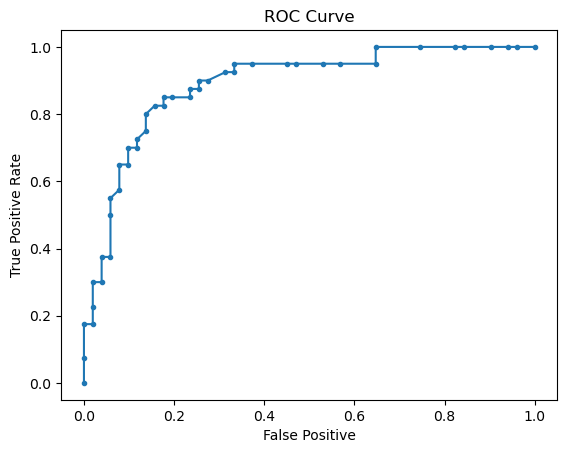

In [89]:
plot_roc_curve(rf_fpr,rf_tpr)

<BarContainer object of 15 artists>

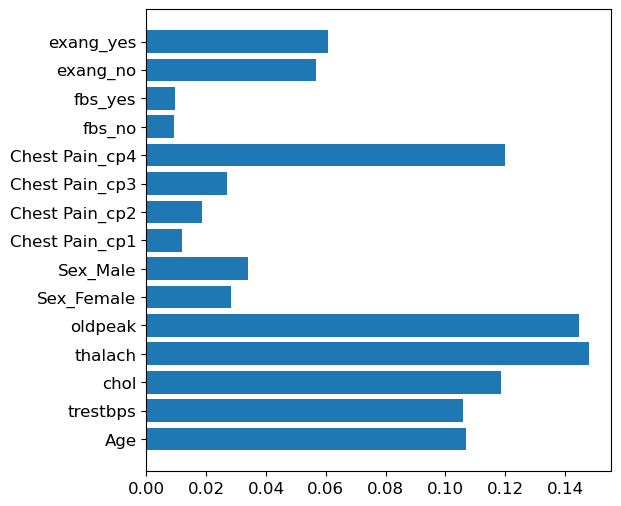

In [93]:
from matplotlib import pyplot as plt
plt.rcParams.update({"figure.figsize":(6,6)})
plt.rcParams.update({"font.size":12})
feature_names=x.columns # lists out the column names for the x #
plt.barh(feature_names, rf.feature_importances_)